Pipeline supervisado para predecir `riesgo_hipertension` a partir del dataset `Hipertension_Arterial_Mexico.csv` (data/raw/).

**Etapas:** carga → EDA → limpieza → split → escalado → entrenamiento (Logistic Regression, Random Forest, Gradient Boosting) → evaluación → selección por F1 → guardado.


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
candidate_paths = [
    "data/raw/Hipertension_Arterial_Mexico.csv",
    "../data/raw/Hipertension_Arterial_Mexico.csv",
    "../../data/raw/Hipertension_Arterial_Mexico.csv",
]

csv_path = next((p for p in candidate_paths if Path(p).exists()), None)
if csv_path is None:
    raise FileNotFoundError("No se encontró Hipertension_Arterial_Mexico.csv en data/raw/")

df = pd.read_csv(csv_path)
print(f"Cargado desde: {csv_path}")
print(f"Shape: {df.shape}")
df.head()


Cargado desde: ../data/raw/Hipertension_Arterial_Mexico.csv
Shape: (4363, 36)


,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_01001004,2,41,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,0.0,107,4,32.889389,120,1
1,2022_01001009,2,65,14.1,9,4.4,3.8,73,130.0,252,...,96.75,152.2,44.5,41.1,113.7,104,2,1.000000,240,0
2,2022_01001012,2,68,14.2,22,4.8,4.0,34,86.0,139,...,68.70,144.8,42.3,37.8,103.7,105,1,1.000000,480,0
3,2022_01001013,1,35,15.7,11,6.5,4.1,49,107.0,203,...,64.70,154.0,48.5,33.5,0.0,117,5,26.265339,275,1
4,2022_01001015,2,65,12.7,7,4.2,4.2,41,76.0,145,...,97.15,161.3,49.6,42.0,118.9,123,2,1.000000,255,0


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 4363 entries, 0 to 4362
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   FOLIO_I                           4363 non-null   str    
 1   sexo                              4363 non-null   int64  
 2   edad                              4363 non-null   int64  
 3   concentracion_hemoglobina         4363 non-null   float64
 4   temperatura_ambiente              4363 non-null   int64  
 5   valor_acido_urico                 4363 non-null   float64
 6   valor_albumina                    4363 non-null   float64
 7   valor_colesterol_hdl              4363 non-null   int64  
 8   valor_colesterol_ldl              4363 non-null   float64
 9   valor_colesterol_total            4363 non-null   int64  
 10  valor_creatina                    4363 non-null   float64
 11  resultado_glucosa                 4363 non-null   float64
 12  valo

,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
count,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,...,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000,4363.000000
mean,1.613339,47.315609,14.228581,21.385973,4.787302,3.868966,36.030254,87.809489,144.138895,0.614573,...,65.789817,153.819940,48.456910,34.061242,19.986340,123.732065,3.239972,22.451292,481.815265,0.645427
std,0.487041,14.445572,1.149723,3.165974,0.820317,0.450879,8.082762,17.530104,28.228483,0.200610,...,7.447041,7.854184,3.488546,4.029785,40.442427,22.608401,2.778287,12.314372,673.702857,0.478438
min,1.000000,4.000000,5.500000,2.000000,0.200000,1.000000,9.000000,11.100000,40.000000,0.060000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,10.000000,0.000000
25%,1.000000,36.000000,14.200000,22.000000,4.800000,4.000000,34.000000,86.000000,139.000000,0.580000,...,64.700000,154.000000,48.500000,33.500000,0.000000,111.000000,2.000000,19.619493,240.000000,0.000000
50%,2.000000,48.000000,14.200000,22.000000,4.800000,4.000000,34.000000,86.000000,139.000000,0.580000,...,64.700000,154.000000,48.500000,33.500000,0.000000,121.000000,3.000000,26.229298,380.000000,1.000000
75%,2.000000,58.000000,14.200000,22.000000,4.800000,4.000000,34.000000,86.000000,139.000000,0.580000,...,64.700000,154.000000,48.500000,33.500000,0.000000,136.000000,4.000000,30.285913,585.000000,1.000000
max,2.000000,93.000000,19.900000,35.000000,11.000000,5.300000,279.000000,303.000000,681.000000,8.270000,...,151.200000,182.600000,97.300000,105.200000,165.000000,200.000000,99.000000,60.513476,17820.000000,1.000000



=== Distribución de 'riesgo_hipertension' ===
riesgo_hipertension
1    2816
0    1547
Name: count, dtype: int64
riesgo_hipertension
1    0.645
0    0.355
Name: proportion, dtype: float64


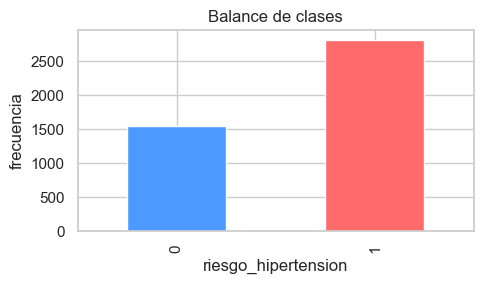

In [3]:
print("=== INFO ===")
df.info()

print("\n=== DESCRIBE ===")
display(df.describe())

target = "riesgo_hipertension"
print(f"\n=== Distribución de '{target}' ===")
print(df[target].value_counts())
print(df[target].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
df[target].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C9AFF", "#FF6B6B"])
ax.set_title("Balance de clases")
ax.set_xlabel(target); ax.set_ylabel("frecuencia")
plt.tight_layout(); plt.show()


=== Nulos por columna ===
Sin valores nulos.

=== Ceros por columna numérica ===
segundamedicion_cintura             3493
riesgo_hipertension                 1547
medida_cintura                      1320
tension_arterial                      29
estatura                              24
distancia_rodilla_talon               14
circunferencia_de_la_pantorrilla      14
segundamedicion_estatura               8
dtype: int64

=== Top 15 correlaciones con riesgo_hipertension ===
masa_corporal                       0.601
peso                                0.584
medida_cintura                      0.535
segundamedicion_cintura            -0.458
edad                               -0.216
segundamedicion_peso               -0.157
circunferencia_de_la_pantorrilla   -0.121
estatura                            0.111
valor_trigliceridos                 0.110
valor_colesterol_ldl                0.091
valor_insulina                      0.083
actividad_total                    -0.083
valor_colesterol_tot

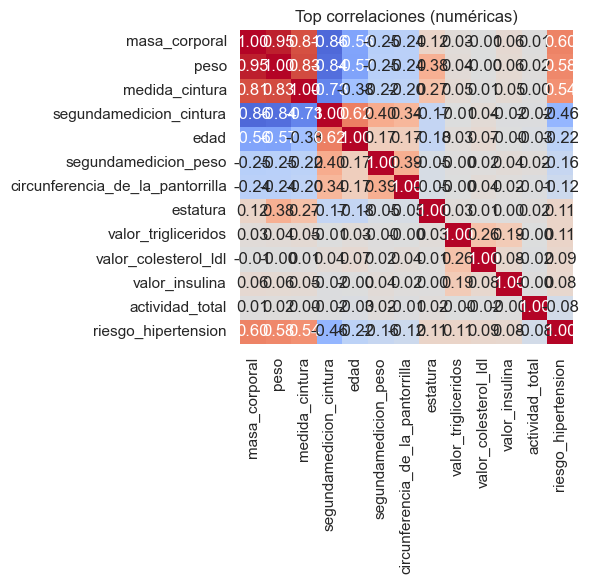

In [4]:
print("=== Nulos por columna ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() else "Sin valores nulos.")

print("\n=== Ceros por columna numérica ===")
num_cols = df.select_dtypes(include=np.number).columns
zeros = (df[num_cols] == 0).sum()
print(zeros[zeros > 0].sort_values(ascending=False))

# correlación de variables numéricas con el target
corr_target = df[num_cols].corr()[target].drop(target).sort_values(key=abs, ascending=False)
print("\n=== Top 15 correlaciones con riesgo_hipertension ===")
print(corr_target.head(15).round(3))

plt.figure(figsize=(6, 6))
sns.heatmap(
    df[num_cols].corr().loc[corr_target.head(12).index.tolist() + [target],
                            corr_target.head(12).index.tolist() + [target]],
    annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=False
)
plt.title("Top correlaciones (numéricas)")
plt.tight_layout(); plt.show()


In [5]:
df_clean = df.copy()

# 1) Quitar columnas tipo ID si existen
id_like = [c for c in df_clean.columns if c.lower() in {"id", "id_paciente", "paciente_id", "folio", "folio_i"}]
if id_like:
    print(f"Drop columnas ID: {id_like}")
    df_clean = df_clean.drop(columns=id_like)

# 2) Codificar 'sexo' si es categórico
if "sexo" in df_clean.columns and df_clean["sexo"].dtype == object:
    mapping = {v: i for i, v in enumerate(sorted(df_clean["sexo"].dropna().unique()))}
    df_clean["sexo"] = df_clean["sexo"].map(mapping)
    print(f"Encoding sexo: {mapping}")

# 3) Ceros clínicamente imposibles -> NaN -> imputar mediana
clinically_nonzero = [
    "glucosa", "presion_sistolica", "presion_diastolica", "hemoglobina",
    "colesterol_total", "colesterol_hdl", "colesterol_ldl", "trigliceridos",
    "peso", "talla", "imc", "masa_corporal", "frecuencia_cardiaca",
]
to_fix = [c for c in clinically_nonzero if c in df_clean.columns and (df_clean[c] == 0).any()]
print(f"Columnas con 0 imposible -> NaN+mediana: {to_fix}")

imputation_medians = {}
for c in to_fix:
    df_clean[c] = df_clean[c].replace(0, np.nan)

# imputar todos los NaN numéricos con mediana
num_cols = df_clean.select_dtypes(include=np.number).columns
for c in num_cols:
    if df_clean[c].isnull().any():
        med = float(df_clean[c].median())
        imputation_medians[c] = med
        df_clean[c] = df_clean[c].fillna(med)

print(f"\nMedianas imputadas: {len(imputation_medians)} columnas")
print(f"Shape final: {df_clean.shape}")
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")
df_clean.head()


Drop columnas ID: ['FOLIO_I']
Columnas con 0 imposible -> NaN+mediana: []

Medianas imputadas: 0 columnas
Shape final: (4363, 35)
Nulos restantes: 0


,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2,41,14.2,22,4.8,4.0,34,86.0,139,0.58,...,64.70,154.0,48.5,33.5,0.0,107,4,32.889389,120,1
1,2,65,14.1,9,4.4,3.8,73,130.0,252,0.62,...,96.75,152.2,44.5,41.1,113.7,104,2,1.000000,240,0
2,2,68,14.2,22,4.8,4.0,34,86.0,139,0.58,...,68.70,144.8,42.3,37.8,103.7,105,1,1.000000,480,0
3,1,35,15.7,11,6.5,4.1,49,107.0,203,0.91,...,64.70,154.0,48.5,33.5,0.0,117,5,26.265339,275,1
4,2,65,12.7,7,4.2,4.2,41,76.0,145,0.71,...,97.15,161.3,49.6,42.0,118.9,123,2,1.000000,255,0


In [6]:
target = "riesgo_hipertension"
X = df_clean.drop(columns=[target])
y = df_clean[target].astype(int)

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Balance train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Balance test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")


Train: (3490, 34), Test: (873, 34)
Balance train: {1: 0.646, 0: 0.354}
Balance test:  {1: 0.645, 0: 0.355}


In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Escalado aplicado (media≈0, std≈1).")


Escalado aplicado (media≈0, std≈1).


In [8]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained, preds, probas = {}, {}, {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    trained[name] = mdl
    preds[name]   = mdl.predict(X_test_s)
    probas[name]  = mdl.predict_proba(X_test_s)[:, 1]
    print(f"✓ {name} entrenado")


✓ LogisticRegression entrenado
✓ RandomForest entrenado
✓ GradientBoosting entrenado


In [9]:
def eval_model(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_proba),
    }

metrics = {name: eval_model(y_test, preds[name], probas[name]) for name in trained}
metrics_df = pd.DataFrame(metrics).T.round(4)
print("=== Métricas en test ===")
display(metrics_df)


=== Métricas en test ===


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.8499,0.8553,0.9236,0.8881,0.9033
RandomForest,0.9920,0.9964,0.9911,0.9938,0.9996
GradientBoosting,0.9977,1.0000,0.9964,0.9982,1.0000


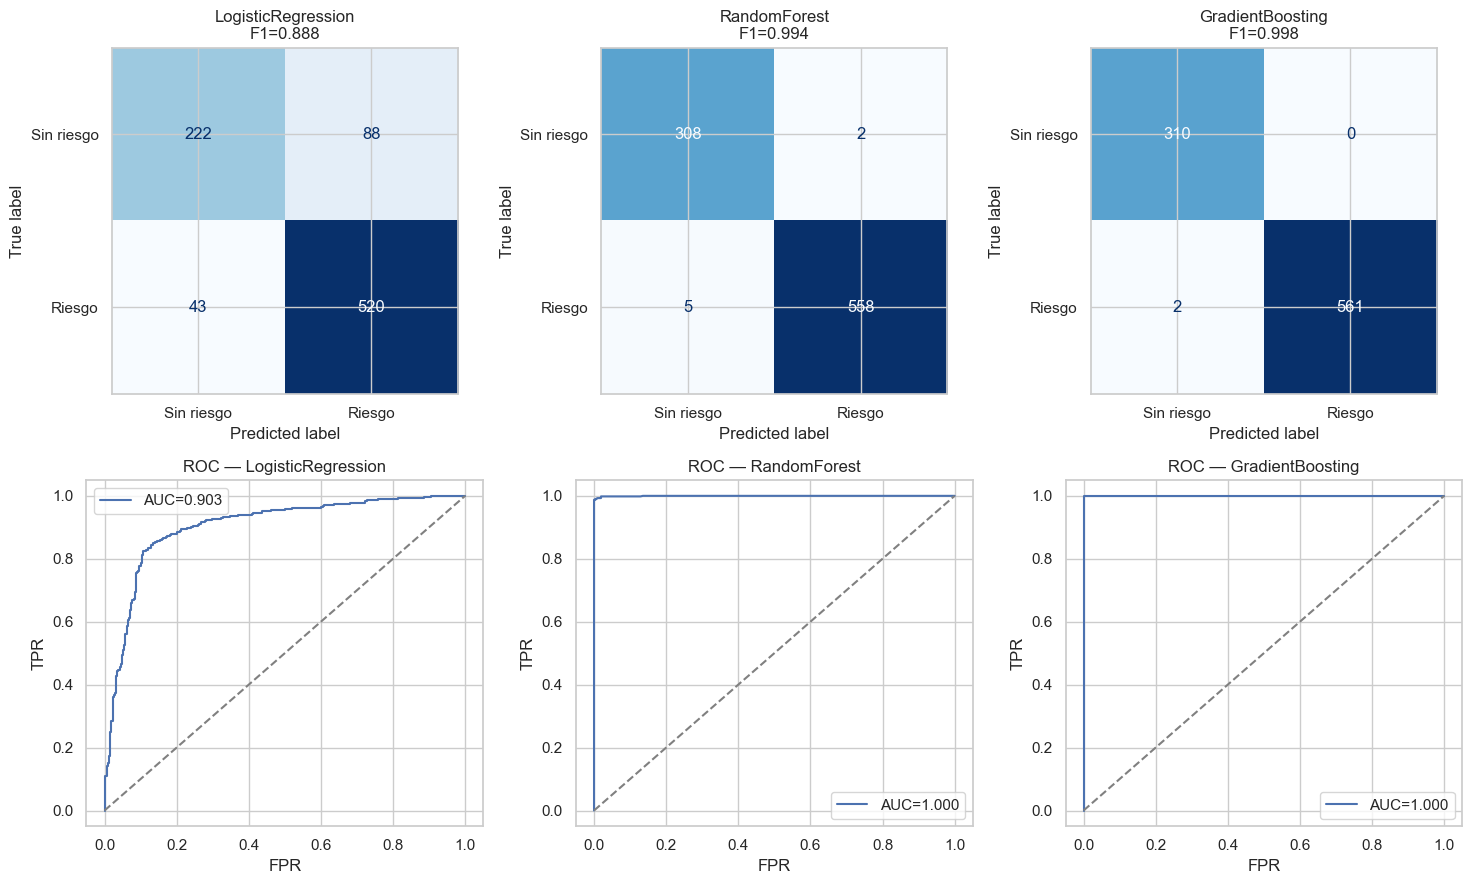

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, (name, mdl) in enumerate(trained.items()):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=["Sin riesgo", "Riesgo"]).plot(
        ax=axes[0, i], cmap="Blues", colorbar=False
    )
    axes[0, i].set_title(f"{name}\nF1={metrics[name]['f1']:.3f}")

    fpr, tpr, _ = roc_curve(y_test, probas[name])
    axes[1, i].plot(fpr, tpr, label=f"AUC={metrics[name]['roc_auc']:.3f}")
    axes[1, i].plot([0, 1], [0, 1], "--", color="gray")
    axes[1, i].set_title(f"ROC — {name}")
    axes[1, i].set_xlabel("FPR"); axes[1, i].set_ylabel("TPR")
    axes[1, i].legend()

plt.tight_layout(); plt.show()


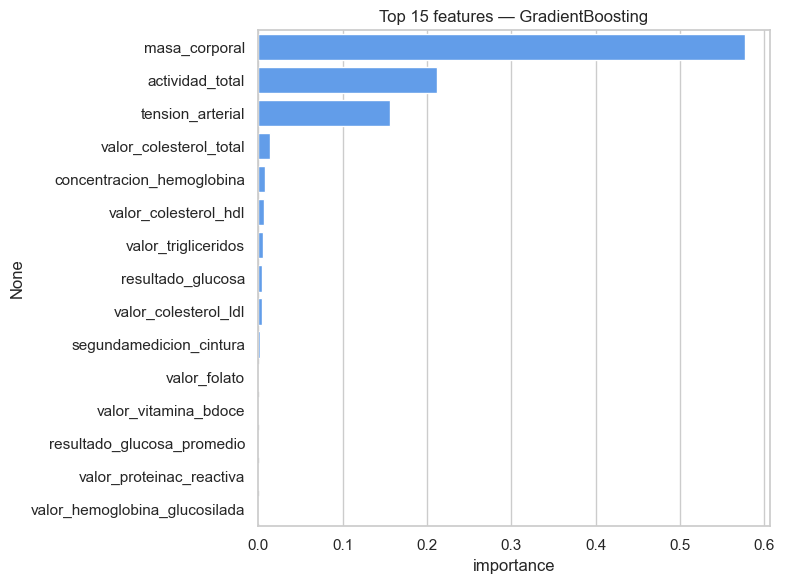

In [11]:
tree_models = {n: m for n, m in trained.items() if hasattr(m, "feature_importances_")}
best_tree = max(tree_models, key=lambda n: metrics[n]["f1"])
imp = pd.Series(trained[best_tree].feature_importances_, index=feature_columns) \
        .sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, color="#4C9AFF")
plt.title(f"Top 15 features — {best_tree}")
plt.xlabel("importance"); plt.tight_layout(); plt.show()


In [12]:
best_name = max(metrics, key=lambda n: metrics[n]["f1"])
best_model = trained[best_name]
print(f"🏆 Mejor modelo por F1: {best_name} (F1={metrics[best_name]['f1']:.4f})")

models_dir = Path("models")
if not models_dir.exists():
    models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

metadata = {
    "target_column": target,
    "class_labels": {"0": "Sin riesgo", "1": "Riesgo de hipertensión"},
    "feature_columns": feature_columns,
    "best_model_name": best_name,
    "models_compared": list(trained.keys()),
    "test_metrics": {n: {k: float(v) for k, v in m.items()} for n, m in metrics.items()},
    "imputation_medians": imputation_medians,
    "random_state": RANDOM_STATE,
    "test_size": 0.2,
    "scaler": "StandardScaler",
}

joblib.dump(best_model, models_dir / "hipertension_best_model.joblib")
joblib.dump(scaler,     models_dir / "hipertension_scaler.joblib")
joblib.dump(
    {"model": best_model, "scaler": scaler, "metadata": metadata},
    models_dir / "hipertension_model.joblib",
)
with open(models_dir / "hipertension_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\nArtefactos guardados en", models_dir.resolve())
for p in ["hipertension_best_model.joblib", "hipertension_scaler.joblib",
          "hipertension_model.joblib", "hipertension_metadata.json"]:
    print(" -", p)


🏆 Mejor modelo por F1: GradientBoosting (F1=0.9982)

Artefactos guardados en /Users/danielsebastianmaciasmacias/Library/CloudStorage/OneDrive-ITESO/Tu-salud/models
 - hipertension_best_model.joblib
 - hipertension_scaler.joblib
 - hipertension_model.joblib
 - hipertension_metadata.json


## Conclusión

Se compararon **Logistic Regression**, **Random Forest** y **Gradient Boosting** sobre el dataset de hipertensión arterial. La selección final se hizo por **F1-score** (criterio médico estándar usado también en los pipelines de diabetes y paro cardíaco).

Artefactos generados en `models/`:
- `hipertension_best_model.joblib` — modelo ganador.
- `hipertension_scaler.joblib` — `StandardScaler` ajustado a train.
- `hipertension_model.joblib` — bundle `{model, scaler, metadata}` para uso en la app.
- `hipertension_metadata.json` — métricas de los 3 modelos, columnas, medianas imputadas.
